In [1]:
# We were forced to restart with new design and new plan for abstraction
# streamline the bridge between prior knowledge and task processing and solution
# ARCSolver starts with: 1) dimensionality 2) background 3) value_list 4) value_map
#                        2) deductive unsupervised classification of a task according to logical screening: saver0
#                        3) the above MUST represent all tasks uniformly and used to encode the task in a form that
#                           the machine can understand

In [2]:
from taskManagerV02 import *

In [3]:
def print_arrays(case_num):
    #print(tt[case_num]['train'])
    plot_task(tt[case_num])
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [4]:
from inductiveV02 import *

In [5]:
from pathlib import Path
data_path = Path('/Users/hassanshallal/Desktop/abstract_reasoning_dataset/abstraction-and-reasoning-challenge/')
training_path = data_path / 'training'
tt = load_set(training_path)

In [6]:
problematic_cases = [19, 32, 22, 24, 33, 3, 4, 6, 11, 12, 17, 27, 31, 34, 23]
cases_of_current_interest = [1, 250, 80, 94, 257, 138, 254, 277, 170, 355, 245, 334, 186, 124, 127, 260, 29, 43, 269,
                            52, 352, 7, 77, 121, 153, 389, 96, 195, 278, 293]   

In [7]:
today_analysis_05212020 = load_serialized('assets/today_analysis_05212020')

In [106]:
def try_captured(this_task):
    # Try
    this_task_output_ver_hor = []
    this_task_output_diag = []
    this_task_output_all = []
    
    if type(this_task.asssignments_output[0]) == str:           
        for n in range(this_task.num_train):
            this_task_output_ver_hor.append(captured_situation_whole(this_task.traininputs[n], 'ver_hor'))
            this_task_output_diag.append(captured_situation_whole(this_task.traininputs[n], 'diag'))
            this_task_output_all.append(captured_situation_whole(this_task.traininputs[n], 'all'))
            

    elif type(this_task.asssignments_output[0]) == list:
        this_couple_result_ver_hor = {}
        this_couple_result_diag = {}
        this_couple_result_all = {}
        for n in range(this_task.num_train):
            for x in range(len(this_task.asssignments_output[n])):
                observables = ['_non' not in x[0] for x in list(this_task.asssignments_output[n][x].keys())]
                target_keys = [y[0] for x, y in zip(observables, list(this_task.asssignments_output[n][x].keys())) if x]
                if len(target_keys) > 1: # this is critical condition because we compare between sets in the same assignment
                    for key, value in this_task.asssignments_output[n][x].items():
                        if key[0] in target_keys:
                            if x not in this_couple_result_ver_hor.keys():
                                this_couple_result_ver_hor[x] = set()
                            this_couple_result_ver_hor[x].add((key[1], captured_situation(this_task.traininputs[n], value[0], 'ver_hor')))
                            if x not in this_couple_result_diag.keys():
                                this_couple_result_diag[x] = set()
                            this_couple_result_diag[x].add((key[1],captured_situation(this_task.traininputs[n], value[0], 'diag')))
                            if x not in this_couple_result_all.keys():
                                this_couple_result_all[x] = set()
                            this_couple_result_all[x].add((key[1],captured_situation(this_task.traininputs[n], value[0], 'all')))
    
    currently_solved_assignments = {}
    if type(this_task.asssignments_output[0]) == str:
        if all([np.unique(x).shape[0] == 1 for x in this_task.trainoutputs]):
            this_task_output_ver_hor = [x[1] for x in this_task_output_ver_hor]
            this_task_output_diag = [x[1] for x in this_task_output_diag]
            this_task_output_all = [x[1] for x in this_task_output_all]
            if all([len(x) == 1 for x in this_task_output_ver_hor]):
                if [x[0][0] for x in this_task_output_ver_hor] == [np.unique(x)[0] for x in this_task.trainoutputs]:
                    candidate_solutions = [np.array([[captured_situation_whole(testinput, 'ver_hor')[1][0][0]]]) for testinput in this_task.testinputs] 
                    if candidate_solutions == this_task.testoutputs:
                        currently_solved_assignments['ver_hor_captured'] = 'This task confirmed a solution based on captured cells ver_hor.'
                    else:
                        currently_solved_assignments['ver_hor_captured'] = "This task didn't generalize a solution based on captured cells ver_hor."
            if all([len(x) == 1 for x in this_task_output_diag]):
                if [x[0][0] for x in this_task_output_diag] == [np.unique(x)[0] for x in this_task.trainoutputs]:
                    candidate_solutions = [np.array([[captured_situation_whole(testinput, 'diag')[1][0][0]]]) for testinput in this_task.testinputs] 
                    if candidate_solutions == this_task.testoutputs:
                        currently_solved_assignments['diag'] = 'This task found a solution based on captured cells diag.'
                    else:
                        currently_solved_assignments['diag'] = "This task didn't generalize a solution based on captured cells diag."
            if all([len(x) == 1 for x in this_task_output_all]):
                if [x[0][0] for x in this_task_output_all] == [np.unique(x)[0] for x in this_task.trainoutputs]:
                    candidate_solutions = [np.array([[captured_situation_whole(testinput, 'all')[1][0][0]]]) for testinput in this_task.testinputs] 
                    if candidate_solutions == this_task.testoutputs:
                        currently_solved_assignments['all'] = 'This task found a solution based on captured cells all.'
                    else:
                        currently_solved_assignments['all'] = "This task didn't generalize a solution based on captured cells all."
            return currently_solved_assignments #[x[1] for x in this_task_output_ver_hor], [x[1] for x in this_task_output_diag], [x[1] for x in this_task_output_all] 
        else:
            print('We need to move onto other first principles. This module can definitely be improved further.')
            pass
            
    elif type(this_task.asssignments_output) == list:
        # we need an assignment tracker system
        which_assignments = {}
        for k, v in this_couple_result_ver_hor.items():
            if len(sorted(list(v))) > 2:
                combs = sorted(list(combinations(sorted(list(v)), 2)))
            elif len(sorted(list(v))) == 2:
                combs = sorted(list(v))
                
                
            for n in range(len(combs)): # this will be the possible pairs of players of an assignment
                if combs[n][0][1] != combs[n][1][1]: # a pair in assignment may be solved
                    if (k, 'ver_hor') not in which_assignments.keys():
                        which_assignments[(k, 'ver_hor')] = []
                    which_assignments[(k, 'ver_hor')].append(combs[n])
        for k, v in this_couple_result_diag.items():
            combs = list(combinations(sorted(list(v)), 2))
            for n in range(len(combs)): # this will be the possible pairs of players of an assignment
                if combs[n][0][1] != combs[n][1][1]: # a pair in assignment may be solved
                    if (k, 'diag') not in which_assignments.keys():
                        which_assignments[(k, 'diag')] = []
                    which_assignments[(k, 'diag')].append(combs[n])
        for k, v in this_couple_result_all.items():
            combs = list(combinations(sorted(list(v)), 2))
            for n in range(len(combs)): # this will be the possible pairs of players of an assignment
                if combs[n][0][1] != combs[n][1][1]: # a pair in assignment may be solved
                    if (k, 'all') not in which_assignments.keys():
                        which_assignments[(k, 'all')] = []
                    which_assignments[(k, 'all')].append(combs[n])
        return which_assignments           

17


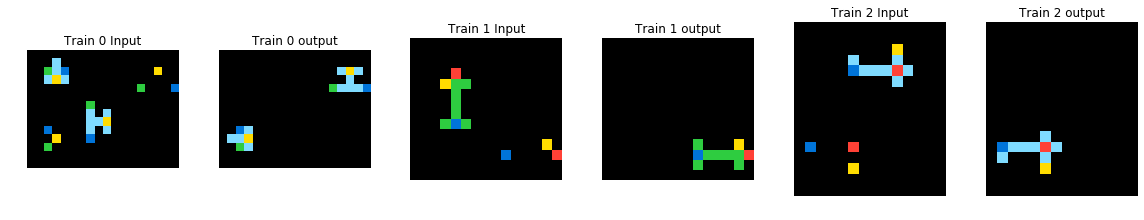

Found MULTIPLE codes: 
is_similar_dim:  True
input_dims info:  [(14, 16, 2), (14, 18, 4)]
output_dims info:  [(14, 16, 2), (14, 18, 4)]
traininputs_vals:  [[0, 1, 3, 4, 8], [0, 1, 2, 3, 4], [0, 1, 2, 4, 8]]
trainoutputs_vals:  [[0, 1, 3, 4, 8], [0, 1, 2, 3, 4], [0, 1, 2, 4, 8]]
couple_val_map:  [{8: {0}, 3: {0}, 1: {0}, 0: {8}, 4: {0}}, {2: {0}, 4: {0}, 3: {0}, 1: {0}, 0: {3}}, {4: {0}, 8: {0}, 1: {0}, 2: {0}, 0: {8}}]
global_bg:  True
bg:  0
deductive_coder0:  ['bg_C', 'bg_S', 'nonbg_C', 'nonbg_S']
deductive_coder1:  ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
global_value_map:  {8: {0}, 3: {0}, 1: {0}, 0: {8, 3}, 4: {0}, 2: {0}}
global_similars:  {0: {0}, 4: {4}, 3: {3}, 1: {1}, 2: {2}}
information about tokenization:
color_to_tokens:  [{0: 'bg', 1: 'nonbg0', 3: 'nonbg1', 4: 'nonbg2', 8: 'nonbg3'}, {0: 'bg', 1: 'nonbg0', 2: 'nonbg1', 3: 'nonbg2', 4: 'nonbg3'}, {0: 'bg', 1: 'nonbg0', 2: 'nonbg1', 4: 'nonbg2', 8: 'nonbg3'}]
token_to_colors:  [{'bg': 0, 'nonbg0': 1, 'nonbg1': 3, 'nonbg2':

In [109]:
for n in [17]:# + cases_of_current_interest + problematic_cases: #coding_situation[1]:
    print(n)
    print_arrays(n)
    this_task = TaskManager(tt[n])
    print(try_captured(this_task))

In [105]:
which_assignment = {(0, 'ver_hor'): [((('bg', 'bg'), False), (('bg', 'nonbg0'), True))]}
len(which_assignment[(0, 'ver_hor')]) == 1, len(which_assignment[(0, 'ver_hor')][0]) == 2

(True, True)

In [73]:
this_trial_ver_hor = {0: {(('bg', 'bg'), False), (('bg', 'nonbg0'), True)}}

In [74]:
len(this_trial_ver_hor)

1

In [80]:
len(this_trial[0]) == len(this_task.asssignments_output[0])

True

In [95]:
this_trial

({0: {(('bg', 'bg'), False), (('bg', 'nonbg0'), True)}},
 {0: {(('bg', 'bg'), False), (('bg', 'nonbg0'), False)}},
 {0: {(('bg', 'bg'), False), (('bg', 'nonbg0'), False)}})

0
2
True


In [89]:
from itertools import permutations, combinations


In [72]:
type(this_trial)

tuple

In [68]:
this_trial

{'diag': 'This task found a solution based on captured cells diag.',
 'all': 'This task found a solution based on captured cells all.'}

In [23]:
inputs = this_task.traininputs
outputs = this_task.trainoutputs

In [24]:
all([np.unique(x).shape[0] == 1 for x in outputs])

True

In [25]:
[np.unique(x)[0] for x in outputs]

[2, 8, 1, 8]

In [26]:
all([len(x) == 1 for x in this_trial[0]])

False

In [27]:
all([len(x) == 1 for x in this_trial[1]])

True

In [28]:
[x[0][0] for x in this_trial[1]] == [np.unique(x)[0] for x in outputs]

True

In [42]:
np.array([[[captured_situation_whole(traininput, 'diag')[1] for traininput in this_task.testinputs][0][0][0]]]) == this_task.testoutputs

array([[[ True]]])

In [56]:
[np.array([[captured_situation_whole(traininput, 'diag')[1][0][0]]]) for traininput in this_task.traininputs] == this_task.trainoutputs

True

In [82]:
this_trial[0]

[[[2, (2, 2)]],
 [[8, (3, 6)]],
 [[2, (7, 1)], [1, (7, 2)], [2, (8, 2)]],
 [[3, (8, 3)], [8, (8, 4)]]]

In [69]:
all([len(x) == 1 for x in this_trial[2]])

True

In [77]:
[x[0][0] for x in this_trial[2]] == [np.unique(x)[0] for x in outputs]

True

In [ ]:
def 

In [45]:
[x.shape for x in outputs][0][0] * [x.shape for x in outputs][0][1]

1

In [43]:
[x.shape for x in inputs][0][0] * [x.shape for x in inputs][0][1]

[(5, 9), (7, 9), (11, 9), (11, 12)]

19


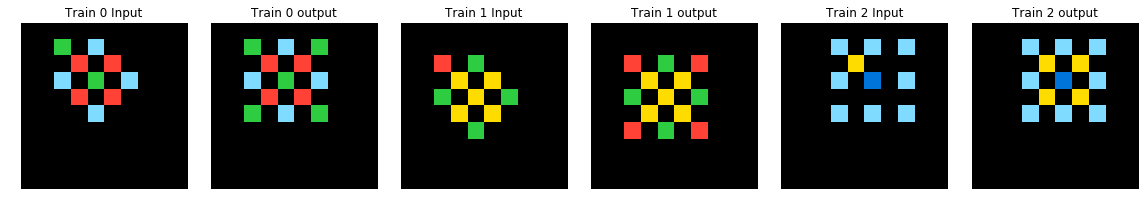

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): True}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}]
===
32


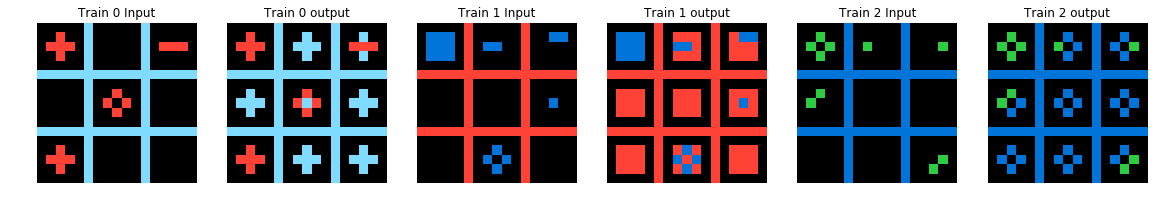

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}]
===
22


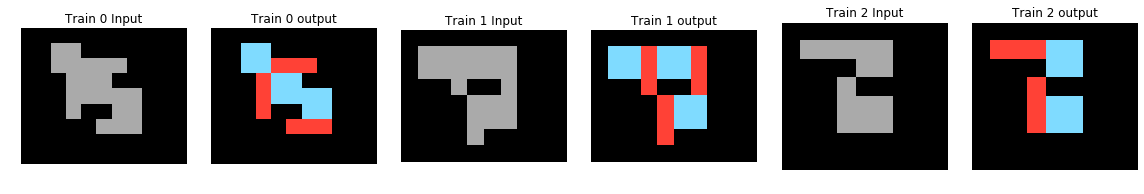

[{('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}]
===
[{('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}]
===
[{('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False, ('diff_anchor', ('nonbg0', 'nonbg2')): False}]
===
24


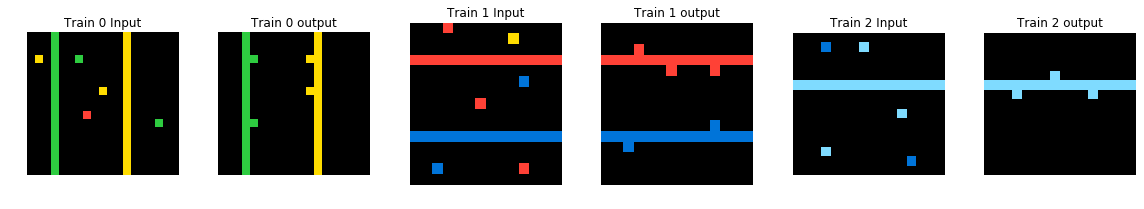

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}, {('token_anchor', ('nonbg2', 'nonbg2')): False, ('diff_anchor', ('nonbg2', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}, {('diff_anchor', ('nonbg2', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')):

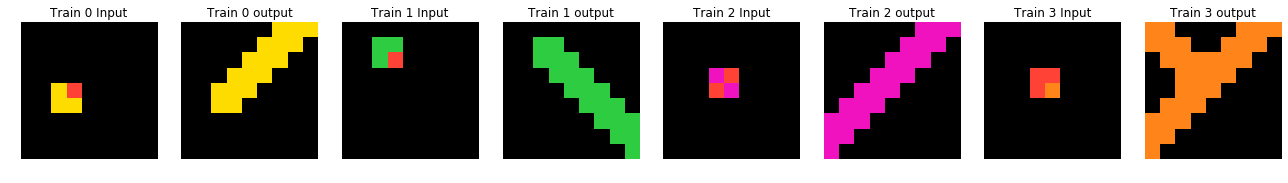

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('diff_anchor', ('nonbg0', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg1')): Fa

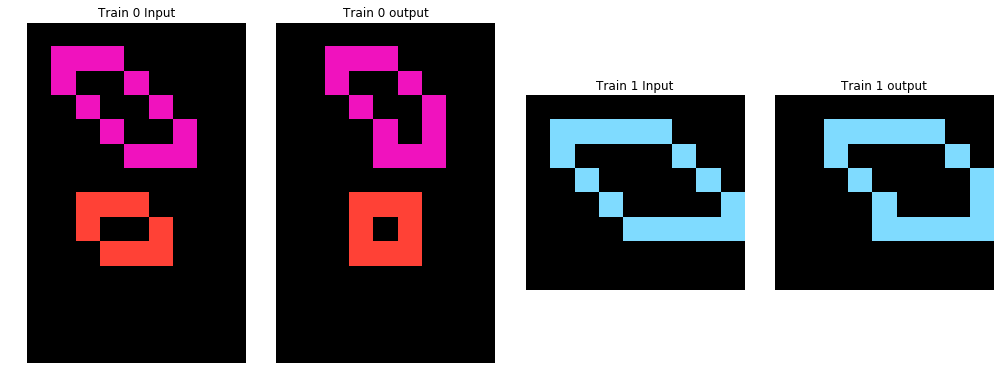

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}]
===
[{('token_anchor', ('bg', 'b

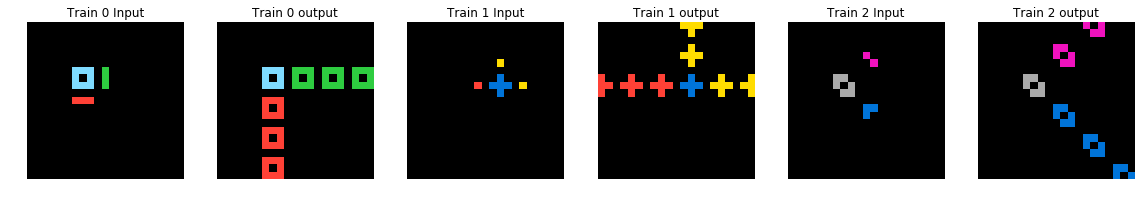

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')

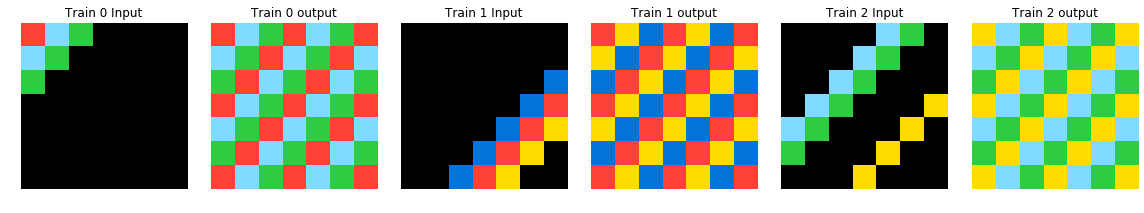

[{('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}]
===
[{('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}]
===
[{('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_a

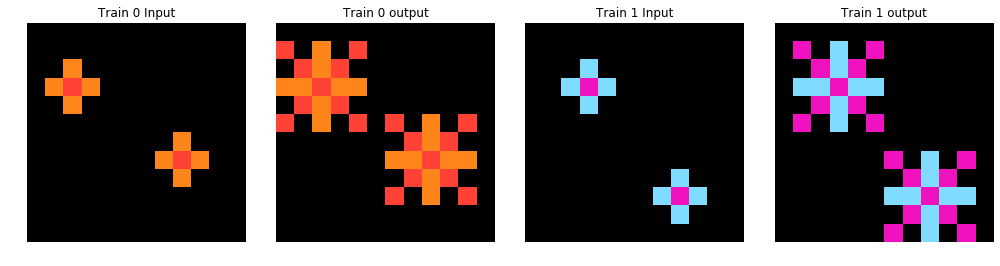

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
12


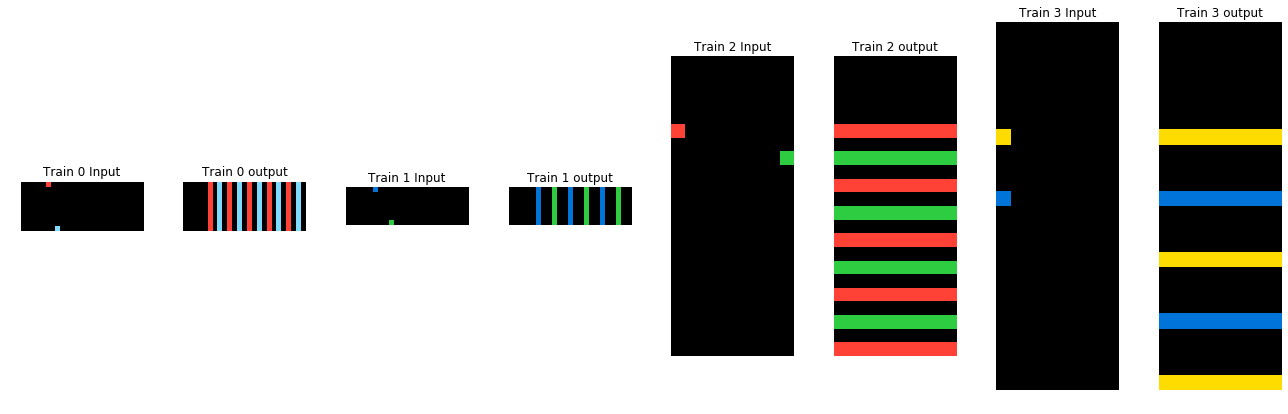

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): Fa

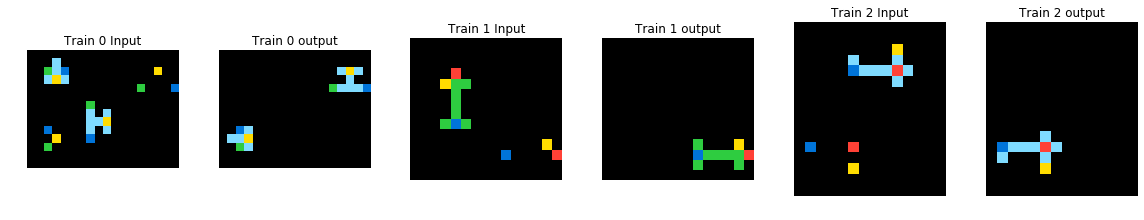

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg3')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}, {('token_anchor', ('nonbg2', 'nonbg2')): False, ('diff_anchor', ('nonbg2', 'bg')): False}, {('diff_anchor', ('nonbg3', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg1', 'nonbg1')): False, ('diff_anchor', ('nonbg1', 'bg')): False}, {('diff_anchor', ('nonbg2', 'bg')): False}, {('token_anchor', ('nonbg3', 'nonbg3')): False, ('diff_anchor', ('nonbg3', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg3')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('token_anchor', ('nonbg

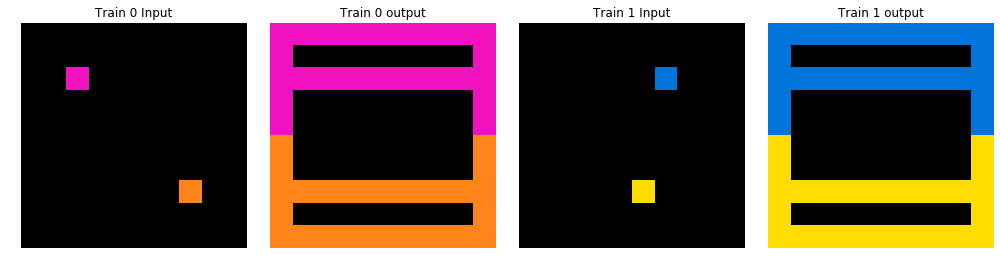

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}]
===
31


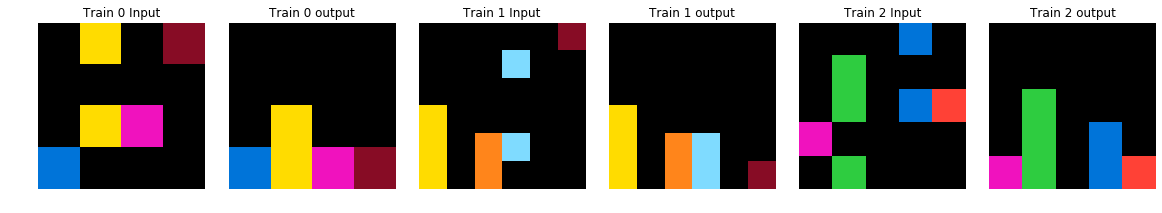

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('diff_anchor', ('nonbg1', 'bg')): False}, {('diff_anchor', ('nonbg2', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False}, {('token_anchor', ('nonbg0', 'nonbg0')): False, ('diff_anchor', ('nonbg0', 'bg')): False}, {('diff_anchor', ('nonbg1', 'bg')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False, ('diff_anchor', ('bg', 'nonbg3')): False}, {('diff_anchor', ('nonbg0', 'bg')): False}, {('diff_anchor', ('nonbg1', 'bg')): False}, {('token_anchor', ('nonbg2', 'nonbg2')): False, ('diff_anchor', ('nonbg2', 'bg')): False}, {('di

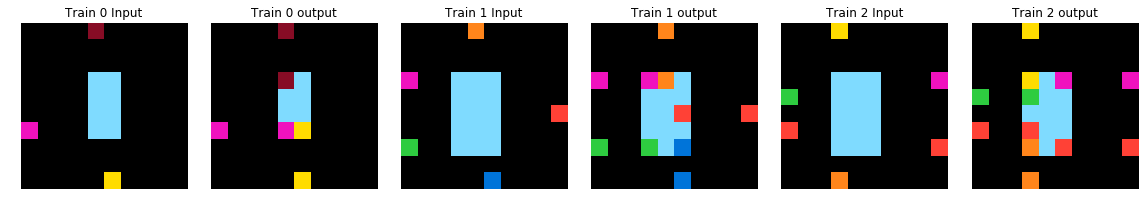

[{('token_anchor', ('nonbg2', 'nonbg2')): False, ('diff_anchor', ('nonbg2', 'nonbg0')): False, ('diff_anchor', ('nonbg2', 'nonbg1')): False, ('diff_anchor', ('nonbg2', 'nonbg3')): False}, {('token_anchor', ('nonbg5', 'nonbg5')): False, ('diff_anchor', ('nonbg5', 'nonbg0')): False, ('diff_anchor', ('nonbg5', 'nonbg1')): False, ('diff_anchor', ('nonbg5', 'nonbg2')): False, ('diff_anchor', ('nonbg5', 'nonbg3')): False, ('diff_anchor', ('nonbg5', 'nonbg4')): False}, {('token_anchor', ('nonbg5', 'nonbg5')): False, ('diff_anchor', ('nonbg5', 'nonbg0')): False, ('diff_anchor', ('nonbg5', 'nonbg1')): False, ('diff_anchor', ('nonbg5', 'nonbg2')): False, ('diff_anchor', ('nonbg5', 'nonbg3')): False, ('diff_anchor', ('nonbg5', 'nonbg4')): False}]
===
[{('token_anchor', ('nonbg2', 'nonbg2')): False, ('diff_anchor', ('nonbg2', 'nonbg0')): False, ('diff_anchor', ('nonbg2', 'nonbg1')): False, ('diff_anchor', ('nonbg2', 'nonbg3')): False}, {('token_anchor', ('nonbg5', 'nonbg5')): False, ('diff_anchor'

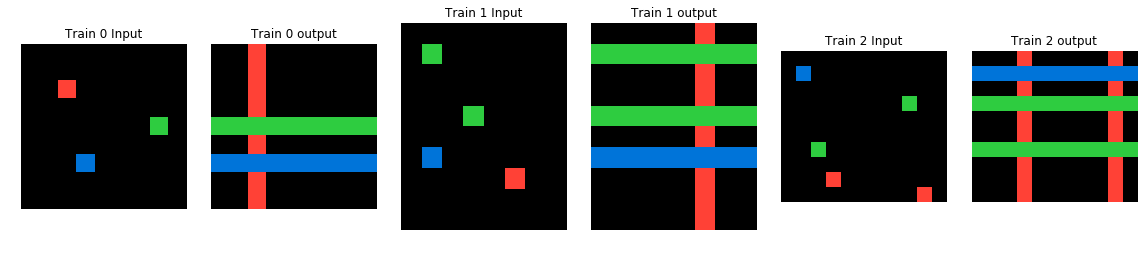

[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}]
===
[{('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): False}, {('token_anchor', ('bg', 'bg')): False, ('diff_anchor', ('bg', 'nonbg0')): False, ('diff_anchor', ('bg', 'nonbg1')): False, ('diff_anchor', ('bg', 'nonbg2')): 

In [9]:
for task_num in cases_of_current_interest + problematic_cases:
    print(task_num)
    plot_task(tt[task_num])
    this_task = deepcopy(today_analysis_05212020[task_num])
    this_task_output_ver_hor = []
    this_task_output_diag = []
    this_task_output_all = []

    for n in range(this_task.num_train):

        if type(this_task.asssignments_output[0]) == str:
            this_task_output_ver_hor.append(captured_situation_whole(this_task.traininputs[n], 'ver_hor'))
            this_task_output_diag.append(captured_situation_whole(this_task.traininputs[n], 'diag'))
            this_task_output_all.append(captured_situation_whole(this_task.traininputs[n], 'all'))
        
        elif type(this_task.asssignments_output[n]) == list:
            for x in range(len(this_task.asssignments_output[n])):
                observalbles = ['_non' not in x[0] for x in list(this_task.asssignments_output[n][x].keys())]
                target_keys = [y[0] for x, y in zip(observalbles, list(this_task.asssignments_output[n][x].keys())) if x]
                this_couple_result_ver_hor = {}
                this_couple_result_diag = {}
                this_couple_result_all = {}
                for key, value in this_task.asssignments_output[n][x].items():
                    if key[0] in target_keys:
                        this_couple_result_ver_hor[key] = captured_situation(this_task.traininputs[n], value[0], 'ver_hor')
                        this_couple_result_diag[key] = captured_situation(this_task.traininputs[n], value[0], 'diag')
                        this_couple_result_all[key] = captured_situation(this_task.traininputs[n], value[0], 'all')
                this_task_output_ver_hor.append(this_couple_result_ver_hor)
                this_task_output_diag.append(this_couple_result_diag)
                this_task_output_all.append(this_couple_result_all)
                
    if type(this_task.asssignments_output[0]) == str:                
        print([x[1] for x in this_task_output_ver_hor], this_task.trainoutputs)
        print('---')
        print([x[1] for x in this_task_output_diag], this_task.trainoutputs)
        print('---')
        print([x[1] for x in this_task_output_all], this_task.trainoutputs)
        print('---')
    elif type(this_task.asssignments_output) == list:
        print(this_task_output_ver_hor)
        print('===')
        print(this_task_output_diag)
        print('===')
        print(this_task_output_all)
        print('===')

    # [x[1] for x in this_task_output], this_task.trainoutputs
    # this_task_output

In [46]:
this_task_output_ver_hor

[{('token_anchor', ('bg', 'bg')): False,
  ('diff_anchor', ('bg', 'nonbg0')): True},
 {('token_anchor', ('bg', 'bg')): False,
  ('diff_anchor', ('bg', 'nonbg0')): True},
 {('token_anchor', ('bg', 'bg')): False,
  ('diff_anchor', ('bg', 'nonbg0')): True},
 {('token_anchor', ('bg', 'bg')): False,
  ('diff_anchor', ('bg', 'nonbg0')): True},
 {('token_anchor', ('bg', 'bg')): False,
  ('diff_anchor', ('bg', 'nonbg0')): True}]

In [38]:
[x[1] for x in this_task_output_all], this_task.trainoutputs
# this_task_output

([[[2, (2, 2)]], [[8, (3, 6)]], [[1, (7, 2)]], [[8, (8, 4)]]],
 [array([[2]]), array([[8]]), array([[1]]), array([[8]])])

In [ ]:
# develop an observer/observable class, the observale is get_method()'token_anchor' != 'diff_anchor')
# in caught cases
# In non caught cases, you need to problem graph inputs, apply holistically on the input, for example, captured will
# be on all indices as test_points and recurse back from that to values, you may find correlations here right
# to the output and you can maneuver your observer/observable setup accordingly.


In [ ]:
# it is obvious from soem task that first principle relationships between lengths of sets can help narrow down
# the problem into a set of screens

# We are certainly ready for the inductive tomorrow
# go small layers first, don't bother more difficult cases requiring recursive or iterative approaches

# 90 cases out of the 142 tokenized_options[0] to tokenized_options[4] are among the most difficult ones: includes a lot of creation
#
### tokenized_options[0]: "('bg', 'nonbg0')", 56 cases: {"'bg_C', 'bg_S'", "'bg_C', 'bg_S', 'nonbg_S'"}
#                       this case is ideal to understand using reversible rules from output becuase 
#                       when you see a destruction, you should in principle be able to devise a construction using
#                       the opposite first principle
# Task: 1, 250 the easiest way: output: which nonbg cells change an why? == which bg cells change in the input and why?
#                           "'bg_S', 'nonbg_C', 'nonbg_S'"          "'bg_C', 'bg_S', 'nonbg_S'"
#                                    problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]

#  Simple flip from bg_C to nonbg_C and in both cases, you must have a way to extract a question such as?
#               what is the difference between 'bg_C' and bg_S' in input and 
#                       the difference between 'nonbg_C' and 'nonbg_S' in output


# Task 80: bg cells with 3 nonbg neighbours is the one to change any other case don't transpire
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8)]
# Task 94: bg cells with 1 nonbg neighbours is the one to change any other case don't transpire
# Task 257: bg cells with 2 nonbg neighbours is the one to change any other case don't transpire
# Task 138: bg cell with 1, 2, or 3 nonbg neighbours awitch (at least one neigboour)
# Task 254: ongl bg with no neighbours at all change
                # problem_graph: [('bg', 'nonbg0'), (8, 8), ('bg', 'bg'), (1, 1), (2, 2)]
    
# An induction module must offer easy checks such as red versus blue | (can work on output to input but not vice versa)
#                                     captured versus non captured? |  (works on both input and output)
#                                     has neighbours versus has no neighbour? (can work on input to output but can't bring you from output )
#                                     has 3 neighbours versus any other scenario?


# Task 277 is the opposite of finding our what has already been captured, it is the process of finding out
# which one to capture? in this task, you capture any red cells with at least one neighbour?
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2)]

# Task 170 ['bg_C', 'bg_S'] is your base case as far as creation, you have to code it?
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg')]

# Task 355, then 245, 334 is the basic as far as coordinate based line creation is
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (2, 2), (3, 3)]
                # problem_graph:  [('bg', 'nonbg0'), ('bg', 'bg'), (8, 8), (2, 2)]
            

#### tokenized_options[1]: "('bg', 'nonbg0'), ('bg', 'nonbg1')", 22 cases: {"'bg_C', 'bg_S', 'nonbg_S'", "'bg_C', 'nonbg_S'"}
# Task 186: "'bg_C', 'nonbg_S'": captured changes differently than noncaptured
            # problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), (8, 8), (1, 1), (4, 4)]

# Task 124: "'bg_C', 'bg_S', 'nonbg_S'": captured + capturing (combination we talk about)
            # problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'bg'), (6, 6)]
    
# Others are more difficult creation, machine not there yet I guess
#### tokenized_options[2]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2')", 7 cases: {"'bg_C', 'bg_S', 'nonbg_S'", "'bg_C', 'nonbg_S'"}
# more progression of the previous ones, more diversity in creation
#### tokenized_options[3]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3')": 3 cases {"'bg_C', 'bg_S', 'nonbg_S'"}
#### tokenized_options[4]: "('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('bg', 'nonbg3'), ('bg', 'nonbg4')": 2 cases {"'bg_C', 'bg_S', 'nonbg_S'"}


# tokenized_options[6]
# Task 127, 260: basic movement: [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg')]
#                           ['bg_C', 'bg_S', 'nonbg_C_bg']
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('bg', 'nonbg2'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), ('nonbg2', 'bg'), ('bg', 'bg')]


# tokenized_options[8]
# Task 29, 43, 269: selective movement: [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg')]
#                           ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S'] nonbg_S don't move, it is the anchor as far as position
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  ('bg', 'bg'), ('nonbg0', 'nonbg0'), (1, 1), ('nonbg1', 'nonbg1')]
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  (7, 7), ('bg', 'bg'), (5, 5), ('nonbg0', 'nonbg0'), (4, 4)]
# problem_graph:  [('bg', 'nonbg0'), ('bg', 'nonbg1'), ('nonbg0', 'bg'), ('nonbg1', 'bg'), 
#                  ('bg', 'bg'), (2, 2), (1, 1)]

# tokenized_options[10]: 11 case : [('bg', 'nonbg0'), ('nonbg0', 'bg')], ['bg_C', 'bg_S', 'nonbg_C_bg', 'nonbg_S']
# Transitions: 52: most basic movement, just one row down!
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (2, 2)] # wrong, 2 is in fact nonbg0
#              352: green towards yellow!
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (4, 4)]
#             7, 77, 121: movements influneced by coordinate of an attracting object
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (8, 8)]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (1, 1), ('nonbg0', 'nonbg0')]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (3, 3)]

#             153 and 389 are mirror images of each others: same problem_graph
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]
# problem_graph:  [('bg', 'nonbg0'), ('nonbg0', 'bg'), ('bg', 'bg'), (2, 2)]


# tokenized_options[17]: 2 cases: [('nonbg0', 'bg')],  ['bg_S', 'nonbg_C_bg', 'nonbg_S']
#                        Task 96: nonbg with at least one nonbg neighbours survive
# problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (6, 6), (5, 5), (4, 4)] # wrong because 4, 5, 6 are all nonbg0 
#                        Task 192: nonbg with less than two nonbg neghbours disappear
# problem_graph:  [('nonbg0', 'bg'), ('bg', 'bg'), ('nonbg0', 'nonbg0'), (6, 6), (5, 5)] # wrong because 5, 6 are nonbg0
################

# tokenized_options[18]: [('nonbg0', 'bg'), ('nonbg0', 'nonbg1'), ('nonbg0', 'nonbg2')]
#                        ['bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg']
#                         here, max turn to blue and min turn into red and in between vanishes

# tokenized_options[23]: 8 cases, "('nonbg0', 'nonbg1')" ['bg_S', 'nonbg_C_nonbg', 'nonbg_S']
#                       Task 195, 278: only nonbg neighbours of captured bg changes
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]

#                       Task 293: only captured nonbg cells change
# problem_graph:  [('nonbg0', 'nonbg1'), ('bg', 'bg'), ('nonbg0', 'nonbg0')]


# tokenized_options[26]: [('nonbg0', 'nonbg1'), ('nonbg0', 'nonbg2'), ('nonbg0', 'nonbg3'), ('nonbg0', 'nonbg4')]
#                        ['bg_S', 'nonbg_C_nonbg']
#                        nonbg0 changes to colors based on the number of cells: 9, 373
#                         

# tokenized_options[27]: [('nonbg0', 'nonbg1'), ('nonbg1', 'bg')]
#                        ['bg_S', 'nonbg_C_bg', 'nonbg_C_nonbg']
#                        nonbg0 ---> nonbg1, nonbg1 --> bg (nonbg1 is just one cell in the corner): 266


# Some none tokenized non deductive coder cases:
# This belongs to the 186 untokenized cases:
# 0) one color change: 275, 308: there is a global value map
# 00) case 15: consistent value map changes: global_value_map:  {3: {4}, 1: {5}, 2: {6}, 8: {9}, 5: {1}, 6: {2}, 9: {8}, 4: {3}}
# 000) Flips 86, 139, 149, 154, 178, 379
# 1) for n in [222, 268, 288, 306]: there is a simple relationship between the dimensions of the input and the output
#                                and then you apply this to each individual

# 2) case: 338: different dimensions: you just output a numpy array including the nonbg cells
# 3) case 345: output the captured cell value!
# 4) case 290: output the color of the box with captured bg cells
# 5) case 128: output the most frequent value on a similar dimension
# 6) 202, 297: alternating squares lines
# 7) 388: very very important to systematize a change in color: nonbg0--> nonbg1, nonbg1-->nonbg2
# couple_val_map:  [{4: {0}, 5: {4}}, {5: {6}, 6: {0}}, {9: {0}, 5: {9}}]
# here you have to cognify ahha, you shall go 4 --> 0 then 5 --> 4
# 97: all captured nonbg turn into bg
# 119: all captured nonbg turn into the same nonbg
# 191 is a little bit over the 192 case

# for latter but important:
# extracting a shape: 30, 35, 289, 383
# extract then double: 56
# extract and then change color!/translate/scale!
# extract the smallest rectagle: 48, biggest, one towards the corner!
# extract a quadrant with a different color shape: 64
# extract most frequent shape 78
# spatial effects based on dimension of most colors: 114, 177, 212
# 156: movements

In [ ]:
# all 214 must be expressed in form of assignments now
today_analysis_05212020 = []
all_problem_statements = []
all_problem_graphs = []
for n in range(len(tt)):
    print(n)
    plot_task(tt[n])
    this_task = TaskManager(tt[n])
    this_task.brief_task()
    today_analysis_05212020.append(this_task)
    all_problem_statements.append(this_task.problem_statements)
    all_problem_graphs.append(this_task.problem_graph)
    print('^^^^^^^^^^^^^^^^^^^')
serialize(today_analysis_05212020, 'assets/today_analysis_05212020')

In [ ]:
len(today_analysis_05212020)

In [ ]:
coding_situation = {}
coding_situation[0] = []
coding_situation[1] = []
coding_situation[2] = []


for n in range(len(today_analysis_05212020)):
    same_color_to_token = all(x == today_analysis_05212020[n].color_to_tokens[0] for x in today_analysis_05212020[n].color_to_tokens)    
    if type(today_analysis_05212020[n].problem_graph[0]) == str:
        coding_situation[0].append(n)
    elif type(today_analysis_05212020[n].problem_graph[0]) == list and same_color_to_token:
        coding_situation[1].append(n)
    else:
        coding_situation[2].append(n)
        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))
    
# 0  :  186
# 1  :  105: one code
# 2  :  109: multiple codes


In [ ]:
deductive_coder1_to_tokenized = {}
tokenized_to_deductive_coder1 = {}
for n in coding_situation[1]:
    this_task = today_analysis_05212020[n]
    if this_task.deductive_coder1 != None:
        this_task_deductive_coder1 = str(this_task.deductive_coder1).replace('[', '').replace(']', '')
    else:
        this_task_deductive_coder1 = str(None)
        
    if len(this_task.problem_statements) == 0:
        this_task_tokenized = str(None)
    else:
        this_task_tokenized = str(this_task.problem_statements[0]).replace('[', '').replace(']', '')
        
    if this_task_deductive_coder1 not in deductive_coder1_to_tokenized.keys():
        deductive_coder1_to_tokenized[this_task_deductive_coder1] = set()
    deductive_coder1_to_tokenized[this_task_deductive_coder1].add(this_task_tokenized)
    
    if this_task_tokenized not in tokenized_to_deductive_coder1.keys():
        tokenized_to_deductive_coder1[this_task_tokenized] = set()
    tokenized_to_deductive_coder1[this_task_tokenized].add(this_task_deductive_coder1)

print(len(deductive_coder1_to_tokenized), len(tokenized_to_deductive_coder1))
# 16 58

In [ ]:
# Now, that we are able to globally turn a task into a series of problem graphs. It is time to epxeriment
# with solutions